#### Customer Sales Analysis Dashboard


In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('customer_sales_data.csv')

print(df.head())

print(df.columns)

print(df.dtypes)

print(df.shape)

  Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0        C001    Male   52  South          Grocery                6   
1        C002  Female   52   West      Electronics                7   
2        C003    Male   50  North         Clothing                4   
3        C004    Male   22   West          Grocery                3   
4        C005    Male   59   West          Grocery                2   

   Price_Per_Unit Purchase_Date  Total_Amount  
0            1000    2026-01-26          6000  
1             500    2026-02-16          3500  
2            1000    2026-05-01          4000  
3              75    2026-02-25           225  
4             200    2026-04-04           400  
Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')
Customer_ID           str
Gender                str
Age                 int64
Region                str
Product_Categor

In [6]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

print(df.dtypes)

Customer_ID                    str
Gender                         str
Age                          int64
Region                         str
Product_Category               str
Units_Purchased              int64
Price_Per_Unit               int64
Purchase_Date       datetime64[us]
Total_Amount                 int64
dtype: object


In [7]:
# Numpy Calculation

# Average total amount

average_total = np.mean(df['Total_Amount'])

# Average Units Purchased

average_units = np.mean(df['Units_Purchased'])

# Highest Purchase amount

maximum_purchase = np.max(df['Total_Amount'])

# Lowest Purchase amount

minimum_purchase = np.min(df['Total_Amount'])


print("Numpy Calculation")

print("Average Total Amount :", average_total)

print("Average Units Purchased :", average_units)

print("Highest Purchase Amount :", maximum_purchase)

print("Lowest Purchase Amount :", minimum_purchase)

Numpy Calculation
Average Total Amount : 1365.8333333333333
Average Units Purchased : 4.12
Highest Purchase Amount : 7000
Lowest Purchase Amount : 50


In [8]:
# Group Total Sales

Gender_sales = df.groupby("Gender")['Total_Amount'].sum()

print(Gender_sales)


region_sales = df.groupby("Region")['Total_Amount'].sum()

print(region_sales)


category_sales = df.groupby("Product_Category")['Total_Amount'].sum()

print(category_sales)


monthly_sales = df.groupby(
    df['Purchase_Date'].dt.to_period('M')
)['Total_Amount'].sum()

print(monthly_sales)

Gender
Female    118525
Male       86350
Name: Total_Amount, dtype: int64
Region
East     36025
North    61450
South    39625
West     67775
Name: Total_Amount, dtype: int64
Product_Category
Clothing       87300
Electronics    50025
Grocery        67550
Name: Total_Amount, dtype: int64
Purchase_Date
2026-01    35050
2026-02    18950
2026-03    23250
2026-04    51175
2026-05    40675
2026-06    35775
Freq: M, Name: Total_Amount, dtype: int64


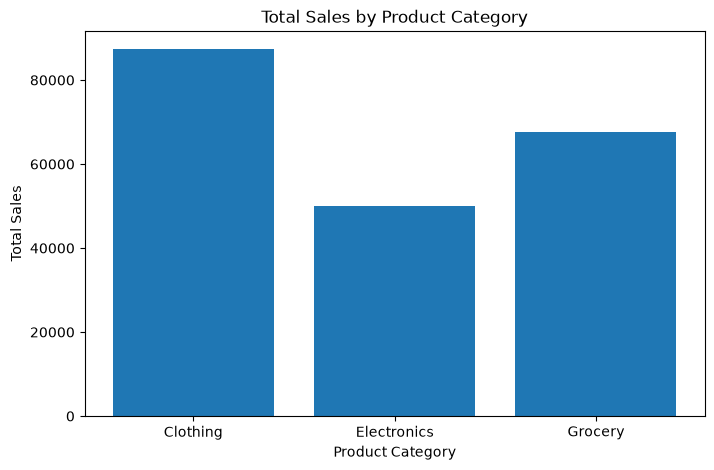

In [9]:
# Bar chart - total sales by Product Category

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Product Category")

plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

Region
West     50
North    39
South    32
East     29
Name: count, dtype: int64


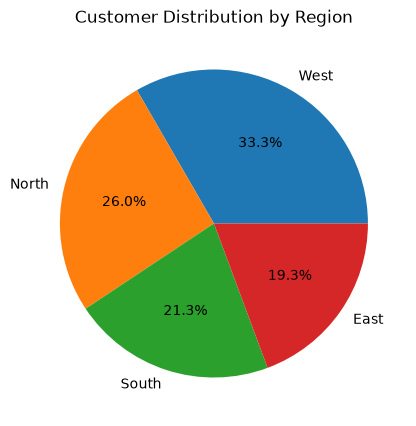

In [10]:
# Customer Distribution by Region

region_customers = df['Region'].value_counts()

print(region_customers)


plt.figure(figsize=(8, 5))

plt.pie(
    region_customers.values,
    labels=region_customers.index,
    autopct="%1.1f%%"
)

plt.title("Customer Distribution by Region")

plt.show()

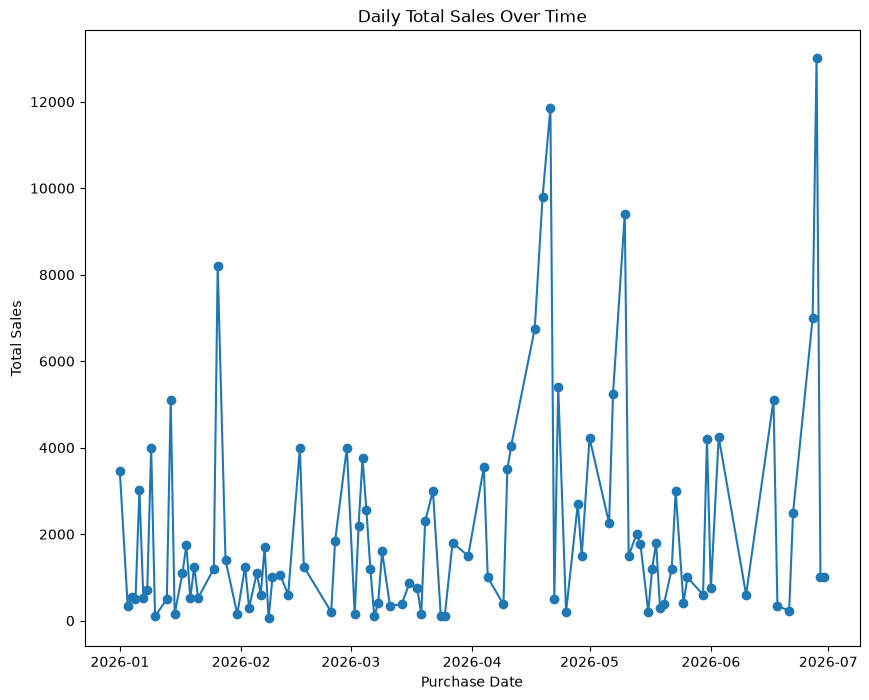

In [11]:
# Daily Total Sales

daily_sales = df.groupby("Purchase_Date")["Total_Amount"].sum()


plt.figure(figsize=(10, 8))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker="o"
)

plt.title("Daily Total Sales Over Time")

plt.xlabel("Purchase Date")

plt.ylabel("Total Sales")

plt.show()

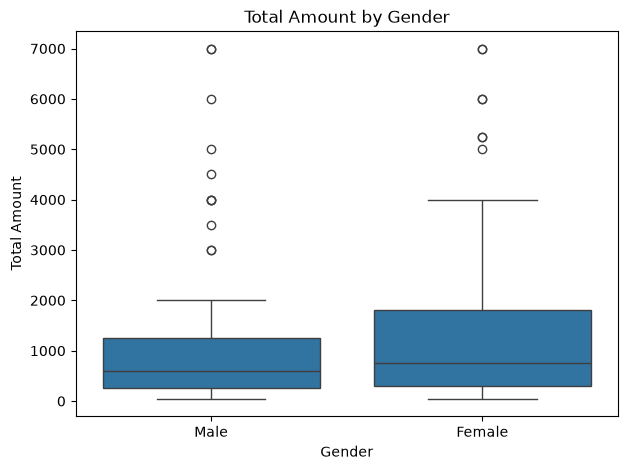

In [12]:
# Seaborn Box Plot

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Gender",
    y="Total_Amount",
    data=df
)

plt.title("Total Amount by Gender")

plt.xlabel("Gender")

plt.ylabel("Total Amount")

plt.show()

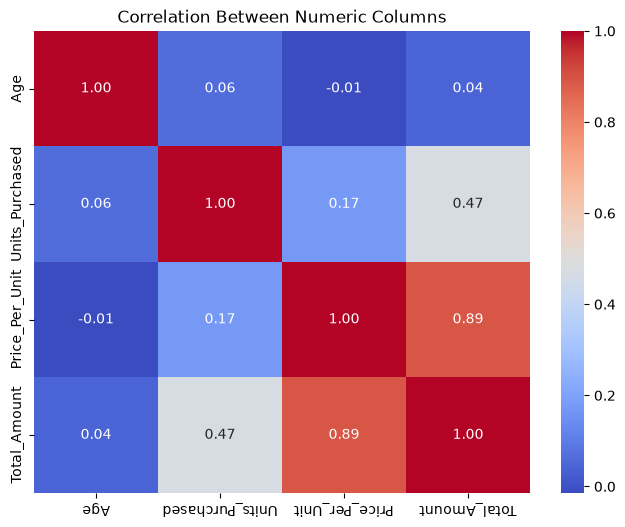

In [13]:
# Heatmap in Seaborn

numeric_columns = df.select_dtypes(include=np.number)

correlation = numeric_columns.corr()


plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.xticks(rotation=180)

plt.title("Correlation Between Numeric Columns")

plt.show()